In [49]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [50]:
# import dtateset (comes with seaborn)
import seaborn as sns
iris = sns.load_dataset('iris')

In [51]:
# Organize data

# Convert data from pandas dataframe to pytorch tensors
data = torch.tensor( iris[iris.columns[0:4]].values ).float()


# transform species to number/label encoding
labels = torch.zeros(len(iris), dtype=torch.long)
# labels[iris['species'] == 'setosa'] = 0    This is commented out because the default value of labels is already 0, so we don't need to assign it again.
labels[iris['species'] == 'versicolor'] = 1
labels[iris['species'] == 'virginica'] = 2

In [52]:
# Creating the model in a function is more suitable in this case because we will be creating multiple models with different number of hidden units(parametric experiment).
def create_iris_model(n_hidden):
    ANNiris = nn.Sequential(
        nn.Linear(4, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 3),
        # nn.Softmax(dim=1)
    )

    # loss function and optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(ANNiris.parameters(), lr=.001)

    return ANNiris, loss_fn, optimizer

In [53]:

def train_model(ANNiris, loss_fn, optimizer, num_epochs):

    # initialize losses
    # losses = torch.zeros(num_epochs)
    
    for _ in range(num_epochs):

        # forward pass
        y_hat = ANNiris(data)

        # Compute loss
        loss = loss_fn(y_hat, labels)
        # losses[epoch] = loss

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # final accuracy
    predictions = ANNiris(data)
    predicted_labels = torch.argmax(predictions, axis=1)

    # Return only final model accuracy after all training is complete
    return 100*torch.mean((predicted_labels == labels).float())


In [ ]:
num_epochs = 150

 
# np.arrange creates an array(list) of number from 1 to 128, with default step of 1. 
# Note, It is similar to Python’s built-in range(1, 129) function, but it returns an array instead of a list.
# This will be the number of hidden units in our model, which we will vary to see how it affects the accuracy.
num_hidden = np.arange(1,129) 
# num_hidden = np.arange(1,129,14) 

accuracies = []

for n in num_hidden:
    ANNiris, loss_fn, optimizer = create_iris_model(n)
    accuracy = train_model(ANNiris, loss_fn, optimizer, num_epochs)
    accuracies.append(accuracy)

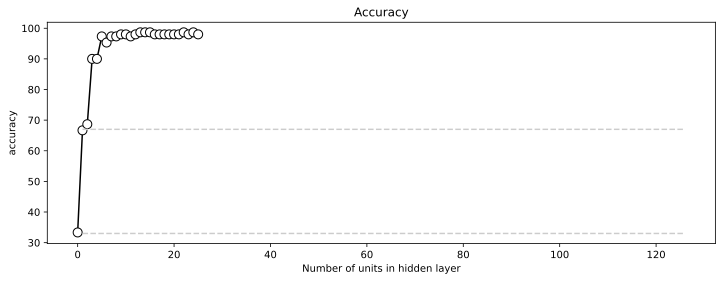

In [58]:
fig, ax = plt.subplots(1, figsize=(12, 4))


ax.plot(accuracies,'ko-',markerfacecolor='w',markersize=9)
ax.plot(num_hidden[[0,-1]],[33,33],'--',color=[.8,.8,.8])
ax.plot(num_hidden[[0,-1]],[67,67],'--',color=[.8,.8,.8])
ax.set_ylabel('accuracy')
ax.set_xlabel('Number of units in hidden layer')
ax.set_title('Accuracy')
plt.show()


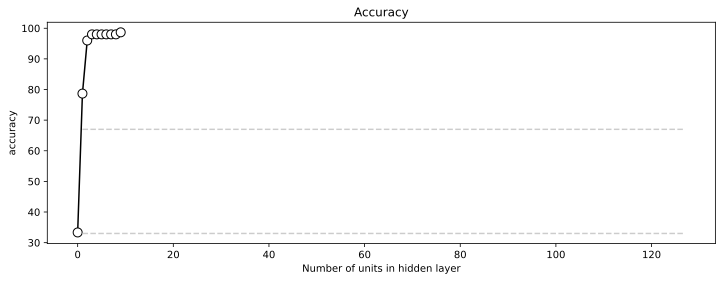

In [56]:
fig, ax = plt.subplots(1, figsize=(12, 4))


ax.plot(accuracies,'ko-',markerfacecolor='w',markersize=9)
ax.plot(num_hidden[[0,-1]],[33,33],'--',color=[.8,.8,.8])
ax.plot(num_hidden[[0,-1]],[67,67],'--',color=[.8,.8,.8])
ax.set_ylabel('accuracy')
ax.set_xlabel('Number of units in hidden layer')
ax.set_title('Accuracy')
plt.show()